In [4]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from src import plot, scaling, metrics, utils

CV_FOLDS=5

In [6]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    data = json.load(f)

selected_obj = []
for obj in data:
    selected_obj.append(obj)

In [30]:
runs = pd.DataFrame(selected_obj)
runs.head()

,ID,dataset,model,prompt,csv_file
0,vy1n12lt,HotpotQA,DeepSeek-V3,cot,vy1n12lt.csv
1,uo2u5m33,HotpotQA,DeepSeek-V3,multistep,uo2u5m33.csv
2,5fdai5h7,HotpotQA,DeepSeek-V3,top-k,5fdai5h7.csv
3,71fhbj6s,MuSiQue,DeepSeek-V3,top-k,71fhbj6s.csv
4,nrs6ugxw,MuSiQue,DeepSeek-V3,direct,nrs6ugxw.csv


In [32]:
def get_run_df(run):
    csv_file = runs_dir / run["csv_file"]
    df = pd.read_csv(csv_file)
    df["dataset"] = run["dataset"]
    return df

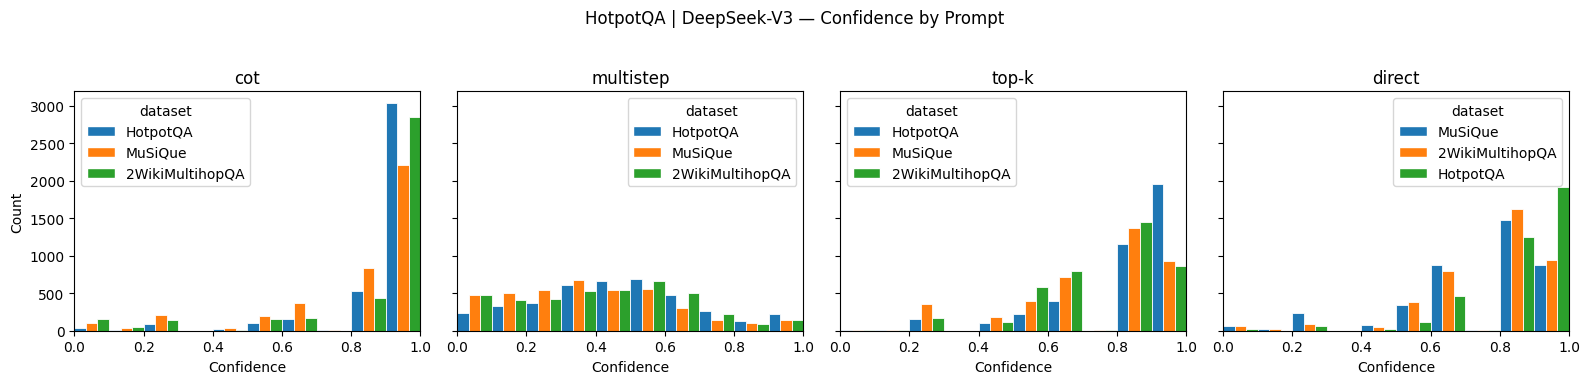

In [42]:
import seaborn as sns

filtered_runs = runs[
    (runs["model"] == "gpt-4o")
]

filtered_runs = runs

parts = []

for _, run in filtered_runs.iterrows():
    df = get_run_df(run).copy()
    parts.append(df[["confidence"]].assign(prompt=run["prompt"]).assign(dataset=run["dataset"]))

plot_df = pd.concat(parts, ignore_index=True)

prompts = list(filtered_runs["prompt"].unique())
n = len(prompts)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)

if n == 1:
    axes = [axes]

for ax, prompt in zip(axes, prompts):
    sub = plot_df[plot_df["prompt"] == prompt]
    sns.histplot(
        data=sub,
        x="confidence",
        hue="dataset",
        multiple="dodge",
        bins=10,
        edgecolor="w",
        alpha=1,
        ax=ax
    )
    ax.set_title(f"{prompt}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Count" if ax is axes[0] else "")

fig.suptitle(f"{filtered_runs['dataset'].iloc[0]} | {filtered_runs['model'].iloc[0]} — Confidence by Prompt")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

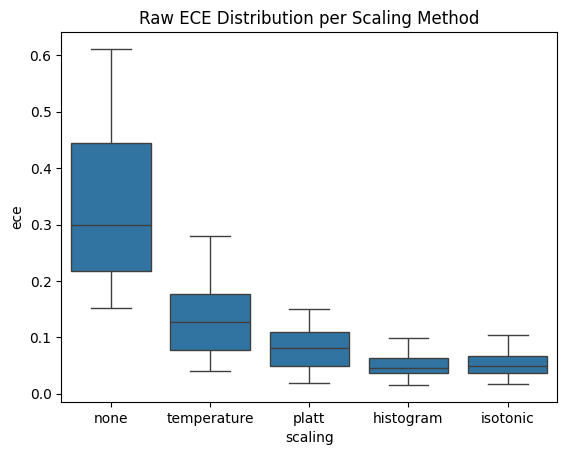

In [136]:
sns.boxplot(
    data=metrics_df,
    x="scaling",
    y="ece",
    order=scaling,
)

plt.title("Raw ECE Distribution per Scaling Method")
plt.show()

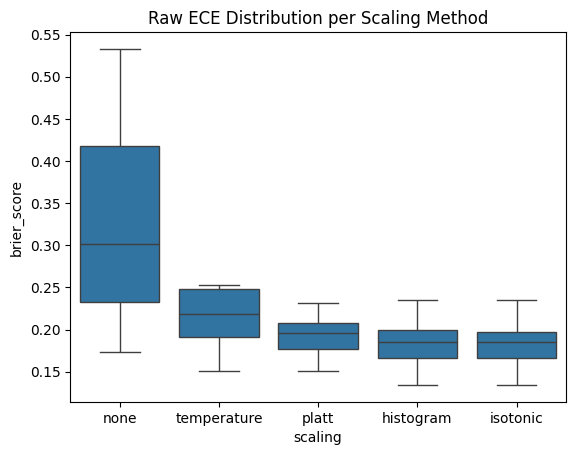

In [134]:
sns.boxplot(
    data=metrics_df,
    x="scaling",
    y="brier_score",
    order=scaling,
)

plt.title("Raw ECE Distribution per Scaling Method")
plt.show()

In [30]:
df_metrics = pd.DataFrame(all_metrics_list)

filtered_df = df_metrics[
    (df_metrics["prompt"].isin(["cot", "multistep"])) &
    (df_metrics["adjust"] == "platt")
]

table = filtered_df.pivot_table(
    index=["dataset", "prompt"],
    values=["brier_score", "ece"]
)

table.round(4)

brier_score     ece
dataset         prompt                        
2WikiMultihopQA cot             0.1959  0.0758
                multistep       0.2012  0.0695
HotpotQA        cot             0.1602  0.0824
                multistep       0.1647  0.0841
MuSiQue         cot             0.2048  0.0388
                multistep       0.2166  0.0714

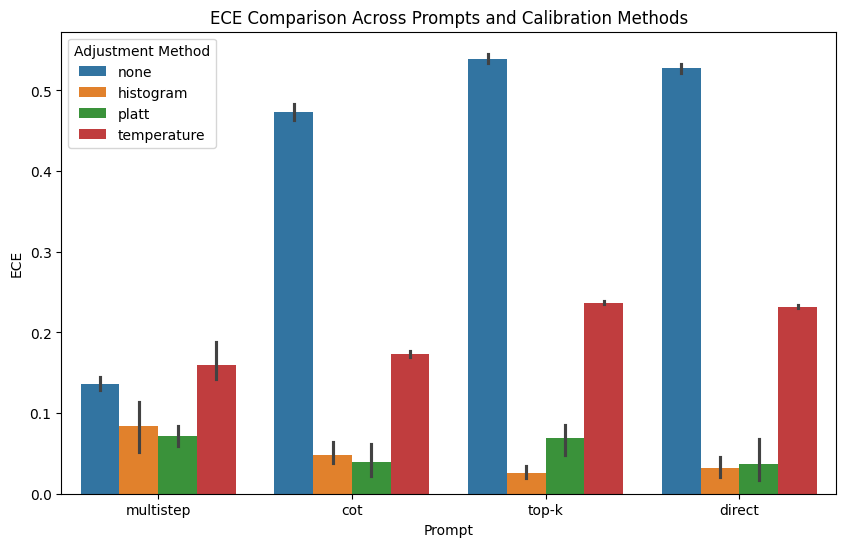

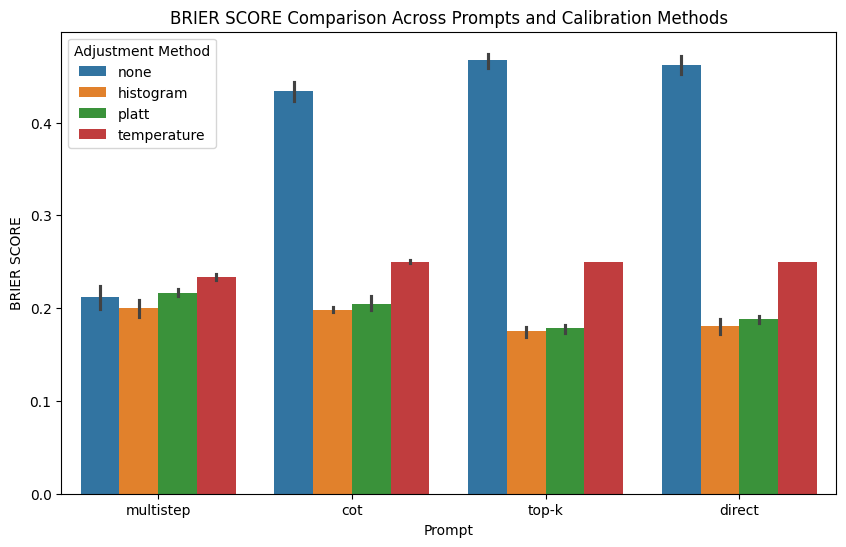

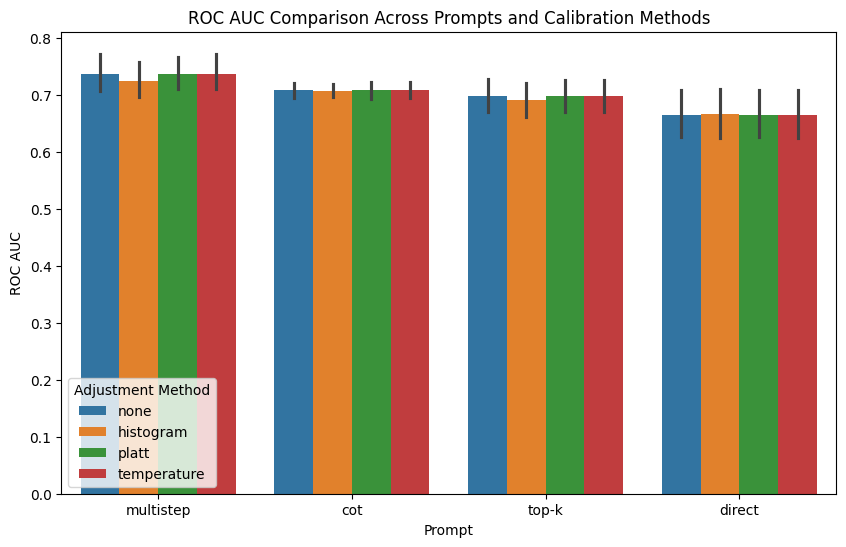

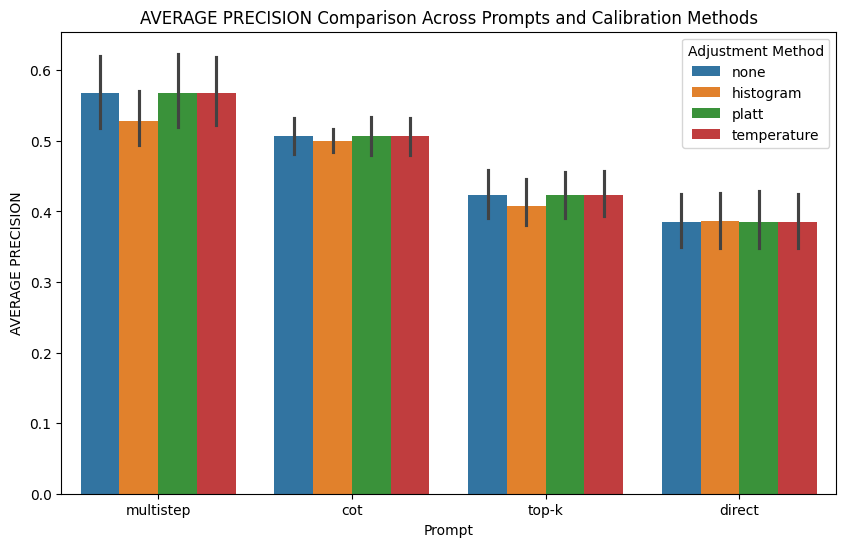

In [27]:
import seaborn as sns

dataset = "MuSiQue"

filtered_df = df_metrics[
    (df_metrics["dataset"] == dataset)
]

metrics_to_plot = ["ece","brier_score", "roc_auc", "average_precision", ]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,6))
    sns.barplot(data=filtered_df, x="prompt", y=metric, hue="adjust", dodge=True)
    plt.ylabel(metric.replace("_", " ").upper())
    plt.xlabel("Prompt")
    plt.title(f"{metric.replace('_', ' ').upper()} Comparison Across Prompts and Calibration Methods")
    plt.legend(title="Adjustment Method")
    #plt.ylim(0, 1)  # Optional, keeps scale consistent for AUC/Brier
    plt.savefig(f"{metric}_comparison.png")
    plt.show()

In [18]:
df_metrics.groupby(["prompt", "adjust"]).agg(
    ece = ("ece", "mean"),
    ece_std = ("ece", "std"),
    roc_auc = ("roc_auc", "mean"),
    roc_auc_std = ("roc_auc", "std"),
    ap = ("average_precision", "mean"),
    ap_std = ("average_precision", "std"),
    brier = ("brier_score", "mean"),
    brier_std = ("brier_score", "std")
)

ece   ece_std   roc_auc  roc_auc_std        ap  \
prompt    adjust                                                             
cot       histogram    0.047848  0.018486  0.707479     0.015771  0.499868   
          none         0.473700  0.012411  0.709481     0.018048  0.507296   
          platt        0.038802  0.025227  0.709481     0.018048  0.507296   
          temperature  0.172754  0.004989  0.709481     0.018048  0.507296   
direct    histogram    0.031300  0.016714  0.665694     0.051973  0.385901   
          none         0.527350  0.007398  0.664845     0.051696  0.385313   
          platt        0.036446  0.034891  0.664845     0.051696  0.385313   
          temperature  0.232018  0.002739  0.664845     0.051696  0.385313   
multistep histogram    0.083807  0.039963  0.723750     0.039976  0.528070   
          none         0.136570  0.009813  0.736402     0.038281  0.567496   
          platt        0.071407  0.015853  0.736326     0.038241  0.567484   
          temperature  0.159001  0.032482  0.736305     0.038310  0.567367   
top-k     histogram    0.026308  0.009325  0.691024     0.038307  0.407481   
          none         0.539550  0.007893  0.698168     0.038838  0.423291   
          platt        0.068580  0.024629  0.698168     0.038838  0.423291   
          temperature  0.237014  0.002738  0.698168     0.038838  0.423291   

                         ap_std     brier  brier_std  
prompt    adjust                                      
cot       histogram    0.021982  0.198432   0.003850  
          none         0.032986  0.433690   0.013170  
          platt        0.032986  0.204802   0.010109  
          temperature  0.032986  0.249473   0.002083  
direct    histogram    0.052063  0.180626   0.009955  
          none         0.049796  0.462208   0.012495  
          platt        0.049796  0.188224   0.005448  
          temperature  0.049796  0.250005   0.000002  
multistep histogram    0.048741  0.200110   0.012043  
          none         0.064966  0.212121   0.016666  
          platt        0.064654  0.216629   0.004817  
          temperature  0.064817  0.233208   0.003890  
top-k     histogram    0.041841  0.175299   0.006736  
          none         0.043131  0.467763   0.009865  
          platt        0.043131  0.178127   0.005995  
          temperature  0.043131  0.250004   0.000001